In [3]:
##################################### IMPORTAMOS LIBRERIAS Y ENTORNO MODELO #############################################

from docplex.mp.model import Model
mdl=Model('modelo')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
inter_1= [70, 30, 10, 10, 10, 1]#O
inter_2= [90, 70, 90, 50, 30, 10]#O

def solve(filename, inter_1, inter_2, seed):
    
    
    random.seed(seed)
    data=Data(filename)
   
    for i in range(1, len(data.q)):
        
        a=random. randint(inter_1, inter_2)/100
        b=random. randint(inter_1, inter_2)/100

        if a<b:
            alpha=a
            betha=b
        else:
            alpha=b
            betha=a
            
        data.q[i]=mt.ceil(random. randint(mt.ceil(data.C*alpha), mt.ceil(data.C*betha)))
        #for j in range()
        
        #data.q[i]=mt.ceil(random.random()*data.q[i])
        
    print(data.C, data.q) 
    
    
    h= min_vehiculos(data.q, data.n, data.C)
    
    
    
    solve_VRP(data.c,data.q,h,data.C, data.n)
    
    VRP_model(data.c,data.q,h,data.C, data.n)#Estaba con #

   
    return 

In [19]:
def modelo2_2(distancia, I, Q, q, k, arcos, coord_x, coord_y):
    

    ################################################## Rangos ##############################################################
    #(i,j)
    Secuencia1={(i,j) for i in range(I) for j in range(I)}
    Secuencia2={(i) for i in range(I)}
    Secuencia3={(i) for i in range(I)}
    Secuencia4={(i,j) for i in range(I) for j in range(I)}

    ################################################### Variables ###########################################################
    #x_ij 
    x=mdl.binary_var_dict(Secuencia1, name='x')
    #u_i//u_j
    u=mdl.continuous_var_dict(Secuencia2, name='u')
    #F_ij
    F=mdl.continuous_var_dict(Secuencia4, name='F')

    ##################################################### FUNCIÓN OBJETIVO ###################################################

    #Minimiza los costos de oportunidad de dictar una asignatura i en un dia d.

    mdl.minimize(mdl.sum(distancia[i,j]*x[i,j] for i in range(I) for j in range(I) if i!=j))

    ########################################################### 2 ############################################################
    for i in range(I):
        if i!=0:
            mdl.add_constraint(mdl.sum(x[i,j] for j in range(I) if i!=j)==1)
        #print(mdl.add_constraint(mdl.sum(x[i,j] for j in range(I) if i!=j)==1))

    ########################################################### 3 ############################################################
    for i in range(I):
        if i!=0:
            mdl.add_constraint(mdl.sum(x[j,i] for j in range(I) if i!=j)==1)

    ########################################################### EXTRA ############################################################
    mdl.add_constraint(mdl.sum(x[0,j] for j in range(I) if i!=j)==k)

    ########################################################### EXTRA II ############################################################
    mdl.add_constraint(mdl.sum(x[j,0] for j in range(I) if i!=j)==k)

    for i in range(I):
        if i!=0:
            mdl.add_constraint(mdl.sum(F[j,i] for j in range(I) if j!=i)+q[i]==mdl.sum(F[i,j] for j in range(I) if j!=i))

    ########################################################### 13 ############################################################
    for i in range(I):
        for j in range(I):
            if i!=j:
                mdl.add_constraint(F[i,j]>=q[i]*x[i,j])

    ########################################################### 14 ############################################################
    for i in range(I):
        for j in range(I):
            if i!=j:
                mdl.add_constraint(F[i,j]<=(Q-q[j])*x[i,j])

    ########################################################### 15 ############################################################
    for i in range(I):
        for j in range(I):
            mdl.add_constraint(F[i,j]>=0)

    ######################################################## EXTRA ######################################################
    for i in range(I):
        mdl.add_constraint(x[i,i]==0)

    solucion=mdl.solve(log_output=True)
    solucion.display()
    mdl.parameters.timelimit=60

    sx=solucion.get_value_dict(x, keep_zeros=True, precision=1)
    sf=solucion.get_value_dict(F, keep_zeros=True, precision=1)

    plt.figure(figsize=(20,15))#Tamaño de la figura
    plt.xlabel("Distancia X")#Nombre del eje x
    plt.ylabel("Distancia Y")#Nombre del eje y
    plt.title("Ubicación de los clientes")#Titulo 

    #Para cuando esta la solucion
    arcos_activos = [i for i in arcos if x[i].solution_value > 0.9]
    #para los arcos activos, las lineas seran de color azul
    for i,j in arcos_activos:
        plt.plot([coord_x[i],coord_x[j]],[coord_y[i],coord_y[j]],
                  color='b', alpha=0.4, zorder=0)
    plt.scatter(x=coord_x, y=coord_y, color='blue', zorder=1)

    #Mostrara el numero del nodo     
    for n in range(len(coord_x)):
        plt.annotate(str(n), xy=(coord_x[n],coord_y[n] ), 
                     xytext=(coord_x[n]+0.5,coord_y[n]+1),color='red')

    plt.xlim((0,100))#de donde a donde va el eje x
    plt.ylim((0,100))#de donde a donde va el eje y
    plt.show()# Muestra el grafico 




Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
Tried aggregator 1 time.
MIP Presolve eliminated 1154 rows and 99 columns.
Reduced MIP has 2178 rows, 2112 columns, and 8318 nonzeros.
Reduced MIP has 1056 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.05 sec. (4.18 ticks)
Found incumbent of value 1738.214386 after 0.11 sec. (12.36 ticks)
Probing time = 0.02 sec. (3.45 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 2178 rows, 2112 columns, and 8318 nonzeros.
Reduced MIP has 1056 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.02 sec. (5.09 ticks)
Probing time = 0.02 sec. (3.39 ticks)
Clique table members: 64.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: deterministic, using up to 8 threads.
Root relaxation solution time = 0.08 sec. (27.45 ticks)

        No

  16134  9092      653.7493   103      662.1101      642.3040   861912    2.99%
  16808  9696      655.9702   112      662.1101      642.5402   928088    2.96%
  17564 10125      649.9906    92      662.1101      642.7434   981650    2.92%
  18259 10544      660.1218    94      662.1101      643.0548  1034118    2.88%
  18966 10891        cutoff            662.1101      643.2996  1083982    2.84%
Elapsed time = 106.47 sec. (26802.63 ticks, tree = 124.10 MB, solutions = 6)
  19600 11265      661.7067   100      662.1101      643.5606  1148925    2.80%
  20286 11642      646.8031    92      662.1101      643.8160  1196781    2.76%
  20951 11934      655.6800   111      662.1101      644.0026  1248179    2.73%
  21666 12339      651.4731   101      662.1101      644.2938  1312597    2.69%
  22241 12696      657.1426    85      662.1101      644.6531  1382696    2.64%
  22898 12904      660.7264    93      662.1101      644.9017  1429936    2.60%
  23539 13284      658.8074    66      662.

  55247  9413        cutoff            662.1101      650.7792  4354759    1.71%
  55811  9675      661.8713    74      662.1101      651.0703  4430395    1.67%
  56470  9833      660.0126    88      662.1101      651.2825  4476341    1.64%
  57118  9933      657.4798    75      662.1101      651.4525  4501896    1.61%
  57664 10095      661.7392    83      662.1101      651.6161  4546899    1.58%
  58243 10183      655.8443    96      662.1101      651.8015  4636495    1.56%
  60693 10568      659.1738    65      662.1101      652.7424  4837622    1.41%
Elapsed time = 439.67 sec. (102427.99 ticks, tree = 80.42 MB, solutions = 6)
  63245 11091      658.9643    59      662.1101      653.4601  5086746    1.31%
  65762 11211      660.8118    47      662.1101      654.0985  5261473    1.21%
  68519 11338        cutoff            662.1101      654.7861  5514895    1.11%
  71388 11095        cutoff            662.1101      655.4700  5727995    1.00%
  74255 10534        cutoff            662.

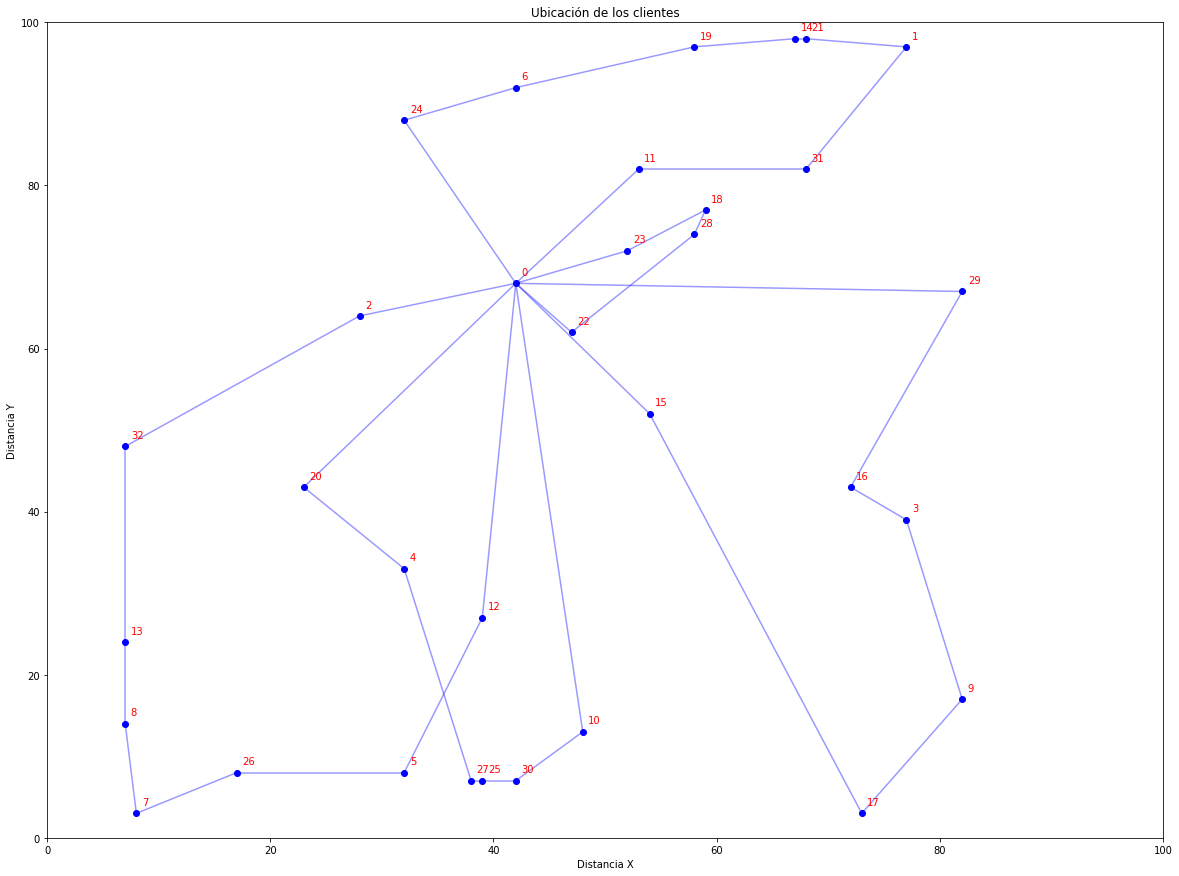

In [20]:
modelo2_2(distancia2, Nodos2, Q2, q2, 5, arcos2, coord_x2, coord_y2 )

Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
CPXPARAM_TimeLimit                               60
1 of 6 MIP starts provided solutions.
MIP start 'm1' defined initial solution with objective 772.9926.
Tried aggregator 1 time.
MIP Presolve eliminated 2308 rows and 198 columns.
Reduced MIP has 4356 rows, 4224 columns, and 16636 nonzeros.
Reduced MIP has 2112 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.05 sec. (8.28 ticks)
Probing time = 0.05 sec. (4.38 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 4356 rows, 4224 columns, and 16636 nonzeros.
Reduced MIP has 2112 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.05 sec. (16.60 ticks)
Probing time = 0.03 sec. (4.01 ticks)
Clique table members: 640.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: deterministi

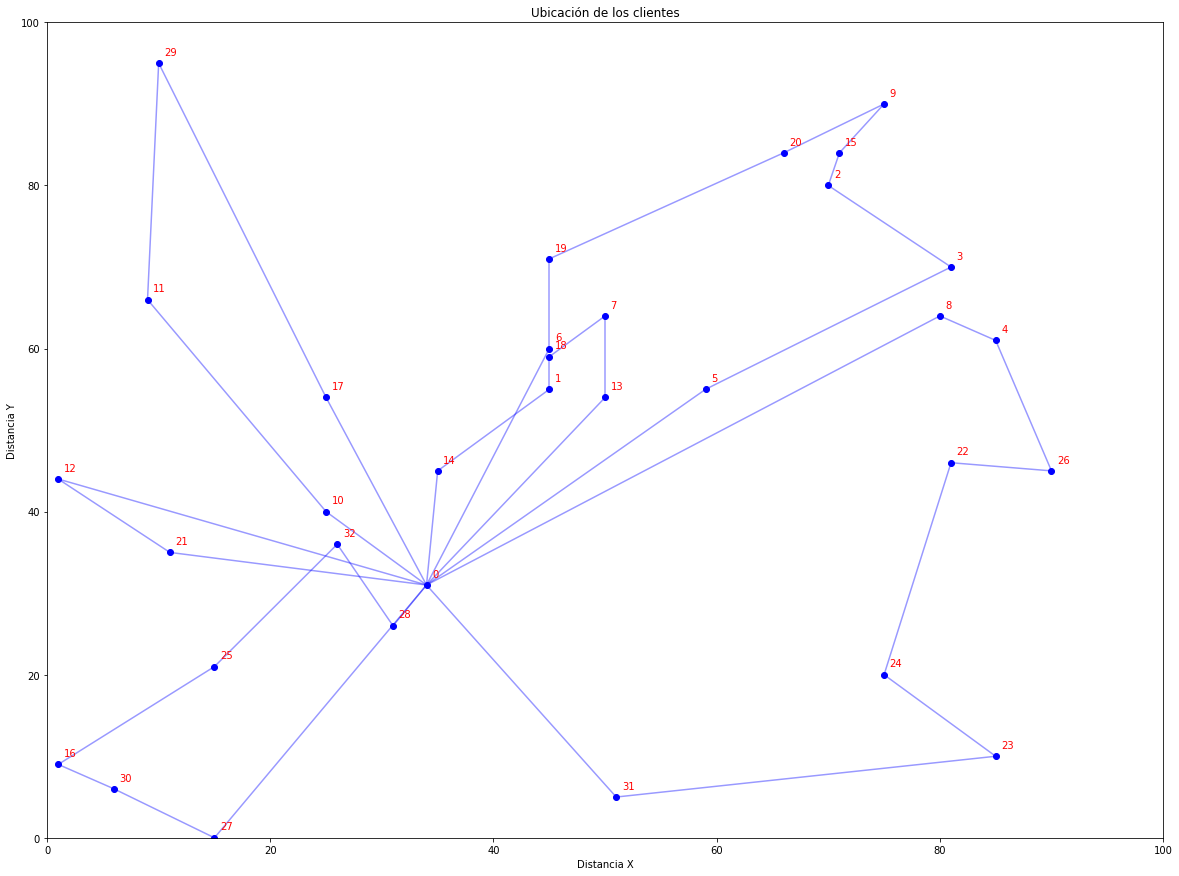

In [21]:
modelo2_2(distancia3, Nodos3, Q3, q3, 6, arcos3, coord_x3, coord_y3 )

Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
CPXPARAM_TimeLimit                               60
1 of 8 MIP starts provided solutions.
MIP start 'm1' defined initial solution with objective 848.2211.
Tried aggregator 1 time.
MIP Presolve eliminated 3531 rows and 300 columns.
Reduced MIP has 6668 rows, 6468 columns, and 25478 nonzeros.
Reduced MIP has 3234 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.05 sec. (12.56 ticks)
Probing time = 0.05 sec. (5.02 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 6668 rows, 6468 columns, and 25478 nonzeros.
Reduced MIP has 3234 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.13 sec. (35.50 ticks)
Probing time = 0.03 sec. (4.59 ticks)
Clique table members: 743.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: determinist

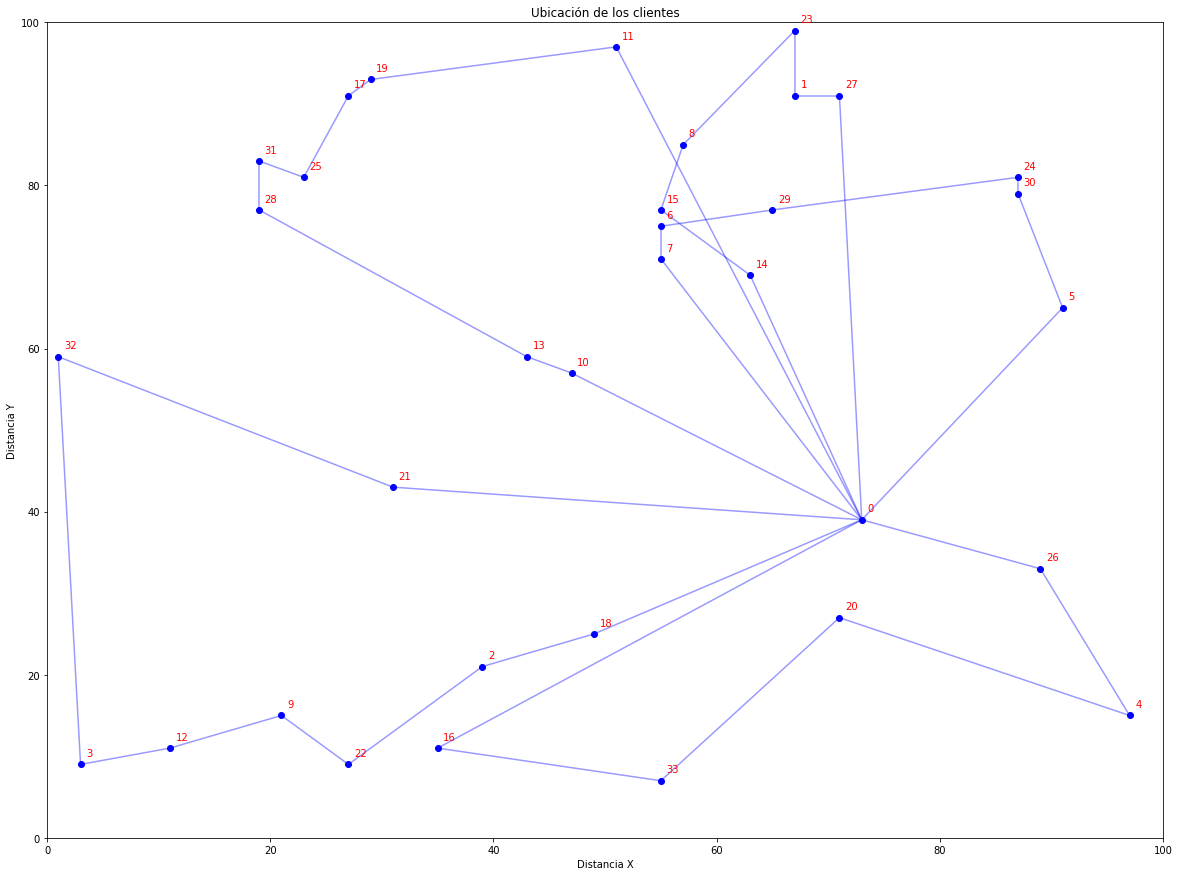

In [22]:
modelo2_2(distancia4, Nodos4, Q4, q4, 5, arcos4, coord_x4, coord_y4 )

In [ ]:
modelo2_2(distancia5, Nodos5, Q5, q5, 5, arcos5, coord_x5, coord_y5 )

Version identifier: 12.10.0.0 | 2019-11-26 | 843d4de2ae
CPXPARAM_Read_DataCheck                          1
CPXPARAM_RandomSeed                              201903125
CPXPARAM_TimeLimit                               60
1 of 5 MIP starts provided solutions.
MIP start 'm1' defined initial solution with objective 829.9277.
Tried aggregator 1 time.
MIP Presolve eliminated 4898 rows and 408 columns.
Reduced MIP has 9260 rows, 8988 columns, and 35416 nonzeros.
Reduced MIP has 4494 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.06 sec. (17.36 ticks)
Probing time = 0.06 sec. (5.75 ticks)
Tried aggregator 1 time.
Detecting symmetries...
Reduced MIP has 9260 rows, 8988 columns, and 35416 nonzeros.
Reduced MIP has 4494 binaries, 0 generals, 0 SOSs, and 0 indicators.
Presolve time = 0.19 sec. (58.04 ticks)
Probing time = 0.03 sec. (5.24 ticks)
Clique table members: 840.
MIP emphasis: balance optimality and feasibility.
MIP search method: dynamic search.
Parallel mode: determinist

In [ ]:
modelo2_2(distancia6, Nodos6, Q6, q6, 5, arcos6, coord_x6, coord_y6 )

In [ ]:
modelo2_2(distancia7, Nodos7, Q7, q7, 6, arcos7, coord_x7, coord_y7 )

In [ ]:
modelo2_2(distancia8, Nodos8, Q8, q8, 6, arcos8, coord_x8, coord_y8 )